<a href="https://colab.research.google.com/github/ThumulaRumesh/Smart-Homes---Indoor-Scene-Recognition-from-Images---CNN/blob/develop/05_ConvNeXt_Tiny.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Step 1 — Imports

In [1]:
import os
import tensorflow as tf
import matplotlib.pyplot as plt

from tensorflow.keras import layers
from tensorflow.keras.applications import ConvNeXtTiny

Step 2 — Dataset paths and classes

In [2]:
dataset_dir = "/content/drive/MyDrive/Colab Notebooks/Y 02 S 02, Advance ML/Assignment/Selected Classes 500"

classes = [
    "kitchen",
    "bedroom",
    "bar",
    "livingroom",
    "warehouse"
]

image_size = (224, 224)
batch_size = 32

train_dir = os.path.join(dataset_dir, "train")
validation_dir = os.path.join(dataset_dir, "validation")
test_dir = os.path.join(dataset_dir, "test")

print("Dataset exists:", os.path.exists(dataset_dir))
print("Training directory exists:", os.path.exists(train_dir))
print("Validation directory exists:", os.path.exists(validation_dir))
print("Test directory exists:", os.path.exists(test_dir))

Dataset exists: True
Training directory exists: True
Validation directory exists: True
Test directory exists: True


Step 3 — Load the same datasets

In [3]:
train_ds = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    labels="inferred",
    label_mode="int",
    class_names=classes,
    color_mode="rgb",
    image_size=image_size,
    batch_size=batch_size,
    shuffle=True,
    seed=42
)

validation_ds = tf.keras.utils.image_dataset_from_directory(
    validation_dir,
    labels="inferred",
    label_mode="int",
    class_names=classes,
    color_mode="rgb",
    image_size=image_size,
    batch_size=batch_size,
    shuffle=False
)

test_ds = tf.keras.utils.image_dataset_from_directory(
    test_dir,
    labels="inferred",
    label_mode="int",
    class_names=classes,
    color_mode="rgb",
    image_size=image_size,
    batch_size=batch_size,
    shuffle=False
)

print("Class names:", train_ds.class_names)

print(
    "Training batches:",
    tf.data.experimental.cardinality(train_ds).numpy()
)

print(
    "Validation batches:",
    tf.data.experimental.cardinality(validation_ds).numpy()
)

print(
    "Test batches:",
    tf.data.experimental.cardinality(test_ds).numpy()
)

Found 2500 files belonging to 5 classes.
Found 482 files belonging to 5 classes.
Found 484 files belonging to 5 classes.
Class names: ['kitchen', 'bedroom', 'bar', 'livingroom', 'warehouse']
Training batches: 79
Validation batches: 16
Test batches: 16


Step 4 — Prefetch

In [4]:
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.prefetch(buffer_size=AUTOTUNE)
validation_ds = validation_ds.prefetch(buffer_size=AUTOTUNE)
test_ds = test_ds.prefetch(buffer_size=AUTOTUNE)

Step 5 — Load ConvNeXt-Tiny

In [5]:
base_model = ConvNeXtTiny(
    include_top=False,
    weights="imagenet", # Use pretrained ImageNet weights for transfer learning
    input_shape=(224, 224, 3)
)

base_model.trainable = False #pretrained feature-extraction layers are frozen initially

print("ConvNeXt-Tiny loaded successfully.")
print("Base model trainable:", base_model.trainable)

111650432/111650432 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
ConvNeXt-Tiny loaded successfully.
Base model trainable: False


Step 6 — Build the classification model

In [6]:
inputs = tf.keras.Input(shape=(224, 224, 3))

x = base_model(inputs, training=False)

x = tf.keras.layers.GlobalAveragePooling2D()(x)

x = tf.keras.layers.Dropout(0.2)(x)

outputs = tf.keras.layers.Dense(
    5,
    activation="softmax"
)(x)

model = tf.keras.Model(inputs, outputs)

print("ConvNeXt-Tiny model created successfully.")

ConvNeXt-Tiny model created successfully.


Step 7 — Check the model

In [7]:
model.summary()

Model: "functional_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_5 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ convnext_tiny (Functional)      │ (None, 7, 7, 768)      │    27,820,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 768)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 768)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 5)              │         3,845 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 27,823,973 (106.14 MB)

 Trainable params: 3,845 (15.02 KB)

 Non-trainable params: 27,820,128 (106.13 MB)

Step 8 - Compile

In [8]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss=tf.keras.losses.SparseCategoricalCrossentropy(),
    metrics=["accuracy"]
)

print("Model compiled successfully.")

Model compiled successfully.


Step 9 — Callbacks

In [9]:
checkpoint_path = "/content/drive/MyDrive/Colab Notebooks/Y 02 S 02, Advance ML/Assignment/convnext_tiny_newclasses.keras"

callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=3,
        restore_best_weights=True
    ),

    tf.keras.callbacks.ModelCheckpoint(
        filepath=checkpoint_path,
        monitor="val_loss",
        save_best_only=True
    )
]

print("Callbacks configured.")

Callbacks configured.


Step 10 — Train

In [10]:
history = model.fit(
    train_ds,
    validation_data=validation_ds,
    epochs=15,
    callbacks=callbacks
)

Epoch 1/15
79/79 ━━━━━━━━━━━━━━━━━━━━ 599s 7s/step - accuracy: 0.7452 - loss: 0.7301 - val_accuracy: 0.8838 - val_loss: 0.3549
Epoch 2/15
79/79 ━━━━━━━━━━━━━━━━━━━━ 17s 207ms/step - accuracy: 0.9040 - loss: 0.3104 - val_accuracy: 0.8900 - val_loss: 0.2918
Epoch 3/15
79/79 ━━━━━━━━━━━━━━━━━━━━ 20s 203ms/step - accuracy: 0.9116 - loss: 0.2585 - val_accuracy: 0.8983 - val_loss: 0.2696
Epoch 4/15
79/79 ━━━━━━━━━━━━━━━━━━━━ 16s 207ms/step - accuracy: 0.9248 - loss: 0.2293 - val_accuracy: 0.9004 - val_loss: 0.2568
Epoch 5/15
79/79 ━━━━━━━━━━━━━━━━━━━━ 16s 200ms/step - accuracy: 0.9256 - loss: 0.2099 - val_accuracy: 0.9087 - val_loss: 0.2486
Epoch 6/15
79/79 ━━━━━━━━━━━━━━━━━━━━ 20s 200ms/step - accuracy: 0.9332 - loss: 0.1965 - val_accuracy: 0.8983 - val_loss: 0.2443
Epoch 7/15
79/79 ━━━━━━━━━━━━━━━━━━━━ 21s 210ms/step - accuracy: 0.9324 - loss: 0.1917 - val_accuracy: 0.9066 - val_loss: 0.2395
Epoch 8/15
79/79 ━━━━━━━━━━━━━━━━━━━━ 19s 197ms/step - accuracy: 0.9360 - loss: 0.1765 - val_accura

Step 11 — Plot the learning curves

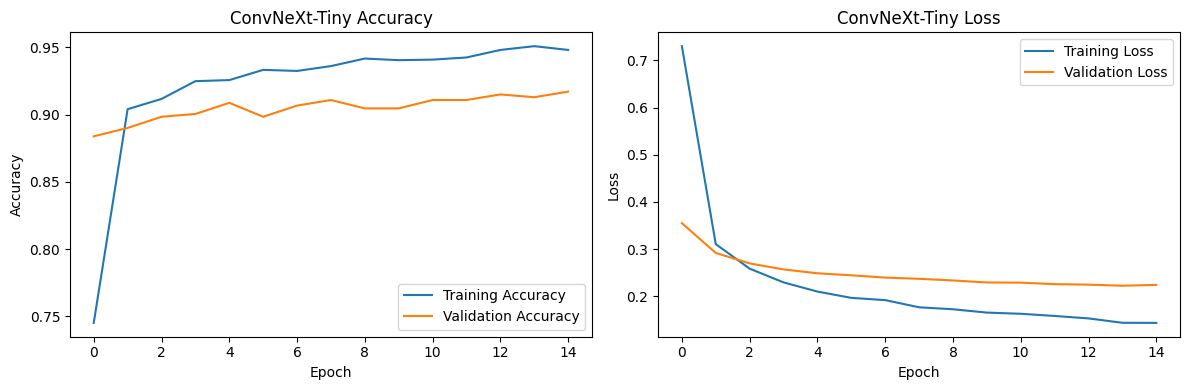

In [11]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("ConvNeXt-Tiny Accuracy")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("ConvNeXt-Tiny Loss")
plt.legend()

plt.tight_layout()
plt.show()

Step 12 — Test evaluation

In [12]:
test_loss, test_accuracy = model.evaluate(test_ds)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)

16/16 ━━━━━━━━━━━━━━━━━━━━ 128s 8s/step - accuracy: 0.9277 - loss: 0.2121
Test Loss: 0.21206413209438324
Test Accuracy: 0.9276859760284424


Step 13 — Load the best checkpoint

In [13]:
# Load the model saved by ModelCheckpoint
best_model = tf.keras.models.load_model(checkpoint_path)

print("Best ConvNeXt-Tiny model loaded successfully.")

Best ConvNeXt-Tiny model loaded successfully.


Step 14 — Evaluate the best checkpoint

In [14]:
test_loss, test_accuracy = best_model.evaluate(test_ds)

print("Best ConvNeXt-Tiny Test Loss:", test_loss)
print("Best ConvNeXt-Tiny Test Accuracy:", test_accuracy)

16/16 ━━━━━━━━━━━━━━━━━━━━ 11s 294ms/step - accuracy: 0.9277 - loss: 0.2121
Best ConvNeXt-Tiny Test Loss: 0.21206413209438324
Best ConvNeXt-Tiny Test Accuracy: 0.9276859760284424


Step 15 - Classification Report

In [15]:
from sklearn.metrics import classification_report
import numpy as np

y_true = []
y_pred = []

for images, labels in test_ds:
    predictions = best_model.predict(images, verbose=0)
    y_true.extend(labels.numpy())
    y_pred.extend(np.argmax(predictions, axis=1))

print(classification_report(
    y_true,
    y_pred,
    target_names=classes,
    digits=4
))

              precision    recall  f1-score   support

     kitchen     0.9906    0.9459    0.9677       111
     bedroom     0.8812    0.8900    0.8856       100
         bar     0.9457    0.9560    0.9508        91
  livingroom     0.8532    0.8774    0.8651       106
   warehouse     0.9868    0.9868    0.9868        76

    accuracy                         0.9277       484
   macro avg     0.9315    0.9312    0.9312       484
weighted avg     0.9289    0.9277    0.9281       484



Step 16 - Confusion Matrix

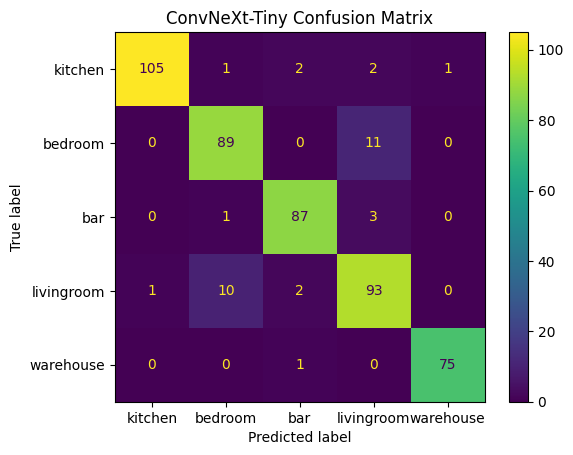

In [16]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_true, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=classes
)

disp.plot()
plt.title("ConvNeXt-Tiny Confusion Matrix")
plt.show()

Step 17 — Final results

In [17]:
correct_predictions = sum(
    np.array(y_true) == np.array(y_pred)
)

incorrect_predictions = sum(
    np.array(y_true) != np.array(y_pred)
)

print("ConvNeXt-Tiny Final Results")
print("----------------------------")
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4%}")
print(f"Correct Predictions: {correct_predictions}")
print(f"Incorrect Predictions: {incorrect_predictions}")

ConvNeXt-Tiny Final Results
----------------------------
Test Loss: 0.2121
Test Accuracy: 92.7686%
Correct Predictions: 449
Incorrect Predictions: 35


Step 18 — Save ConvNeXt-Tiny results

In [18]:
results_dir = "/content/drive/MyDrive/Colab Notebooks/Y 02 S 02, Advance ML/Assignment/Model Results"

os.makedirs(results_dir, exist_ok=True)

In [19]:
import json

report = classification_report(
    y_true,
    y_pred,
    target_names=classes,
    digits=4,
    output_dict=True
)

cm = confusion_matrix(y_true, y_pred)

best_epoch = int(np.argmin(history.history["val_loss"]) + 1)
best_val_loss = float(np.min(history.history["val_loss"]))

convnext_results = {
    "model": "ConvNeXt-Tiny",

    "test_loss": float(test_loss),
    "test_accuracy": float(test_accuracy),

    "correct_predictions": int(correct_predictions),
    "incorrect_predictions": int(incorrect_predictions),

    "total_parameters": int(model.count_params()),
    "trainable_parameters": int(
        np.sum([np.prod(v.shape) for v in model.trainable_weights])
    ),
    "non_trainable_parameters": int(
        np.sum([np.prod(v.shape) for v in model.non_trainable_weights])
    ),

    "best_epoch": best_epoch,
    "best_val_loss": best_val_loss,
    "epochs_completed": len(history.history["loss"]),

    "classes": classes,

    "classification_report": report,

    "confusion_matrix": cm.tolist(),

    "history": {
        "accuracy": [float(x) for x in history.history["accuracy"]],
        "val_accuracy": [float(x) for x in history.history["val_accuracy"]],
        "loss": [float(x) for x in history.history["loss"]],
        "val_loss": [float(x) for x in history.history["val_loss"]]
    }
}

convnext_results_path = os.path.join(
    results_dir,
    "convnext_tiny_results.json"
)

with open(convnext_results_path, "w") as f:
    json.dump(convnext_results, f, indent=4)

print("ConvNeXt-Tiny results saved:")
print(convnext_results_path)

ConvNeXt-Tiny results saved:
/content/drive/MyDrive/Colab Notebooks/Y 02 S 02, Advance ML/Assignment/Model Results/convnext_tiny_results.json
